In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

In [10]:
DATA_PATH = "Video_Games.csv"  # update to match the file name you downloaded

df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df.columns.tolist())
df.head()

(16719, 16)
['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating']


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Standardize column names so the rest of the notebook works regardless of
# exact capitalization/spacing in this dataset version
df.columns = [c.strip().replace(" ", "_") for c in df.columns]

def find_col(possible_names, columns):
    """Case-insensitive match against a list of likely column names."""
    lower_map = {c.lower(): c for c in columns}
    for name in possible_names:
        if name.lower() in lower_map:
            return lower_map[name.lower()]
    return None

col = {
    "name":      find_col(["Name", "Title"], df.columns),
    "platform":  find_col(["Platform"], df.columns),
    "year":      find_col(["Year", "Year_of_Release"], df.columns),
    "genre":     find_col(["Genre"], df.columns),
    "publisher": find_col(["Publisher"], df.columns),
    "na":        find_col(["NA_Sales"], df.columns),
    "eu":        find_col(["EU_Sales"], df.columns),
    "jp":        find_col(["JP_Sales"], df.columns),
    "other":     find_col(["Other_Sales"], df.columns),
    "global":    find_col(["Global_Sales"], df.columns),
    "critic":    find_col(["Critic_Score"], df.columns),
    "user":      find_col(["User_Score"], df.columns),
    "rating":    find_col(["Rating", "ESRB_Rating"], df.columns),
    "developer": find_col(["Developer"], df.columns),
}

print("Detected columns:")
for k, v in col.items():
    print(f"  {k:10s} -> {v}")

Detected columns:
  name       -> Name
  platform   -> Platform
  year       -> Year_of_Release
  genre      -> Genre
  publisher  -> Publisher
  na         -> NA_Sales
  eu         -> EU_Sales
  jp         -> JP_Sales
  other      -> Other_Sales
  global     -> Global_Sales
  critic     -> Critic_Score
  user       -> User_Score
  rating     -> Rating
  developer  -> Developer


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  str    
 1   Platform         16719 non-null  str    
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  str    
 4   Publisher        16665 non-null  str    
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  str    
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  str    
 15  Rating           9950 non-null   str    
dtypes: float64(9), str(7)
memory usage: 2.0 MB


In [13]:
df.isna().sum().sort_values(ascending=False)

User_Count         9129
Critic_Score       8582
Critic_Count       8582
Rating             6769
User_Score         6704
Developer          6623
Year_of_Release     269
Publisher            54
Name                  2
Genre                 2
Platform              0
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
dtype: int64

In [14]:
df_clean = df.dropna(subset=[col["year"], col["publisher"]]).copy()

# User_Score is sometimes stored as text (e.g. "tbd") — coerce to numeric
if col["user"]:
    df_clean[col["user"]] = pd.to_numeric(df_clean[col["user"]], errors="coerce")

df_clean[col["year"]] = df_clean[col["year"]].astype(int)
df_clean = df_clean.drop_duplicates(subset=[col["name"], col["platform"], col["year"]])

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning:  {len(df_clean)}")

Rows before cleaning: 16719
Rows after cleaning:  16416


In [15]:
for key in ["genre", "platform", "publisher"]:
    df_clean[col[key]] = df_clean[col[key]].str.strip()

In [16]:
region_cols = [col["na"], col["eu"], col["jp"]]

genre_region = df_clean.groupby(col["genre"])[region_cols].sum()
genre_region_share = genre_region.div(genre_region.sum(axis=0), axis=1) * 100
genre_region_share = genre_region_share.sort_values(col["na"], ascending=False)
genre_region_share.round(1)

,NA_Sales,EU_Sales,JP_Sales
Genre,,,
Action,19.9,21.3,12.4
Sports,15.5,15.5,10.5
Shooter,13.5,13.1,3.0
Platform,10.3,8.3,10.1
Misc,9.1,8.7,8.3
Racing,8.2,9.8,4.4
Role-Playing,7.6,7.9,27.4
Fighting,5.1,4.1,6.8
Simulation,4.2,4.7,4.9


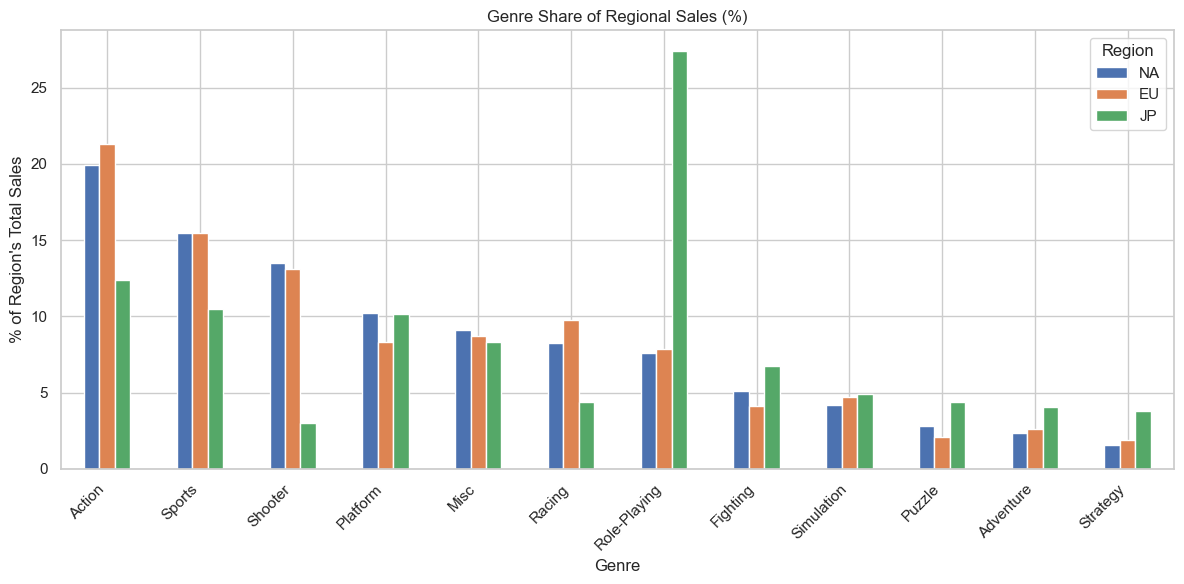

In [17]:
genre_region_share.plot(kind="bar", figsize=(12, 6))
plt.title("Genre Share of Regional Sales (%)")
plt.ylabel("% of Region's Total Sales")
plt.xlabel("Genre")
plt.legend(title="Region", labels=["NA", "EU", "JP"])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

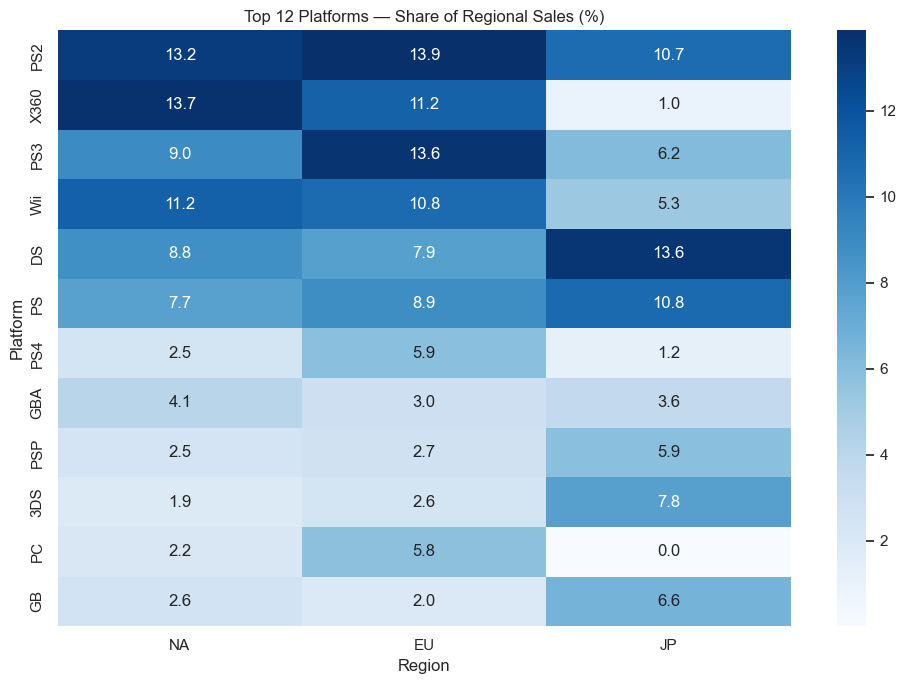

In [18]:
platform_region = df_clean.groupby(col["platform"])[region_cols].sum()
platform_region_share = platform_region.div(platform_region.sum(axis=0), axis=1) * 100

top_platforms = df_clean.groupby(col["platform"])[col["global"]].sum().nlargest(12).index
platform_region_share = platform_region_share.loc[top_platforms]
platform_region_share.columns = ["NA", "EU", "JP"]

plt.figure(figsize=(10, 7))
sns.heatmap(platform_region_share, annot=True, fmt=".1f", cmap="Blues")
plt.title("Top 12 Platforms — Share of Regional Sales (%)")
plt.xlabel("Region")
plt.ylabel("Platform")
plt.tight_layout()
plt.show()

In [19]:
generation_map = {
    "NES": "Gen 3-4 (pre-1994)", "SNES": "Gen 3-4 (pre-1994)", "GB": "Gen 3-4 (pre-1994)",
    "GEN": "Gen 3-4 (pre-1994)", "2600": "Gen 3-4 (pre-1994)",
    "PS": "Gen 5 (1994-1999)", "N64": "Gen 5 (1994-1999)", "SAT": "Gen 5 (1994-1999)",
    "PS2": "Gen 6 (2000-2005)", "XB": "Gen 6 (2000-2005)", "GC": "Gen 6 (2000-2005)",
    "GBA": "Gen 6 (2000-2005)", "DC": "Gen 6 (2000-2005)",
    "PS3": "Gen 7 (2006-2012)", "X360": "Gen 7 (2006-2012)", "Wii": "Gen 7 (2006-2012)",
    "DS": "Gen 7 (2006-2012)", "PSP": "Gen 7 (2006-2012)",
    "PS4": "Gen 8 (2013-2019)", "XOne": "Gen 8 (2013-2019)", "WiiU": "Gen 8 (2013-2019)",
    "3DS": "Gen 8 (2013-2019)", "PSV": "Gen 8 (2013-2019)",
    "PC": "PC (all eras)",
}

df_clean["Generation"] = df_clean[col["platform"]].map(generation_map).fillna("Other/Unmapped")
df_clean["Generation"].value_counts()

Generation
Gen 7 (2006-2012)     7138
Gen 6 (2000-2005)     4310
Gen 8 (2013-2019)     1728
Gen 5 (1994-1999)     1679
PC (all eras)          952
Gen 3-4 (pre-1994)     578
Other/Unmapped          31
Name: count, dtype: int64

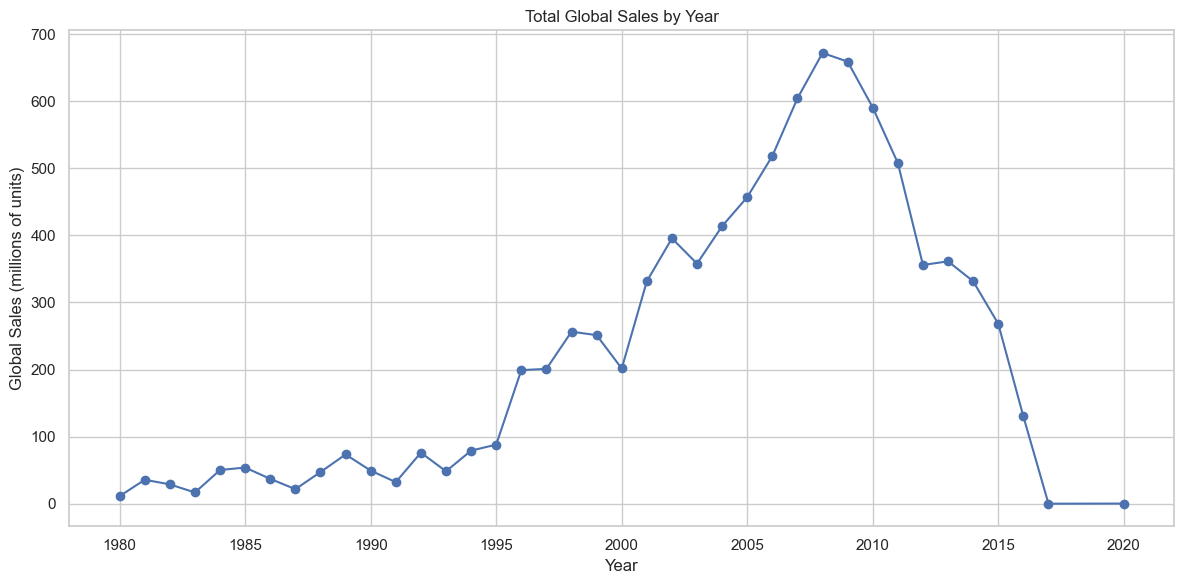

Peak sales year: 2008 (671.8M units)


In [20]:
yearly_sales = df_clean.groupby(col["year"])[col["global"]].sum()

plt.figure(figsize=(12, 6))
yearly_sales.plot(kind="line", marker="o")
plt.title("Total Global Sales by Year")
plt.ylabel("Global Sales (millions of units)")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

peak_year = yearly_sales.idxmax()
print(f"Peak sales year: {peak_year} ({yearly_sales.max():.1f}M units)")

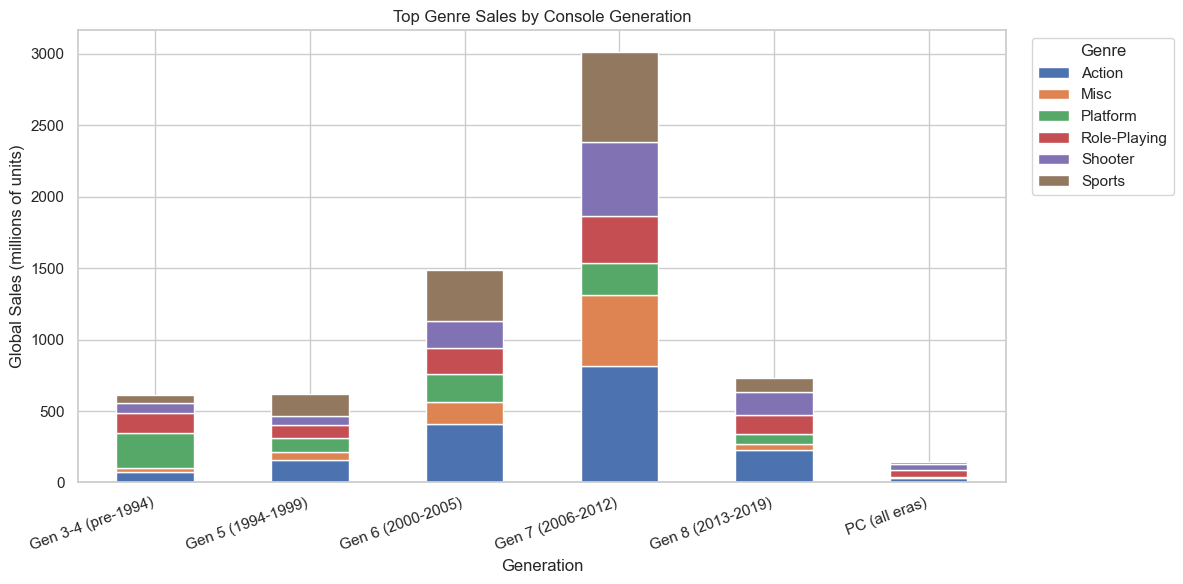

In [21]:
gen_genre = (
    df_clean[df_clean["Generation"] != "Other/Unmapped"]
    .groupby(["Generation", col["genre"]])[col["global"]]
    .sum()
    .reset_index()
)

gen_order = ["Gen 3-4 (pre-1994)", "Gen 5 (1994-1999)", "Gen 6 (2000-2005)",
             "Gen 7 (2006-2012)", "Gen 8 (2013-2019)", "PC (all eras)"]
gen_genre["Generation"] = pd.Categorical(gen_genre["Generation"], categories=gen_order, ordered=True)

top_genres = df_clean.groupby(col["genre"])[col["global"]].sum().nlargest(6).index
pivot = gen_genre[gen_genre[col["genre"]].isin(top_genres)].pivot(
    index="Generation", columns=col["genre"], values=col["global"]
)

pivot.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Top Genre Sales by Console Generation")
plt.ylabel("Global Sales (millions of units)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [22]:
has_scores = col["critic"] is not None

if has_scores:
    score_df = df_clean.dropna(subset=[col["critic"]]).copy()
    print(f"Games with a Critic_Score: {len(score_df)} of {len(df_clean)}")

    corr = score_df[[col["critic"], col["global"]]].corr().iloc[0, 1]
    print(f"Correlation (Critic_Score vs Global_Sales): {corr:.3f}")

    if col["user"]:
        user_df = score_df.dropna(subset=[col["user"]])
        corr_user = user_df[[col["user"], col["global"]]].corr().iloc[0, 1]
        print(f"Correlation (User_Score vs Global_Sales): {corr_user:.3f}")
else:
    print("Critic_Score column not found — check df.columns from Cell 2 "
          "and update the `find_col` list in Cell 3.")

Games with a Critic_Score: 7981 of 16416
Correlation (Critic_Score vs Global_Sales): 0.245
Correlation (User_Score vs Global_Sales): 0.088


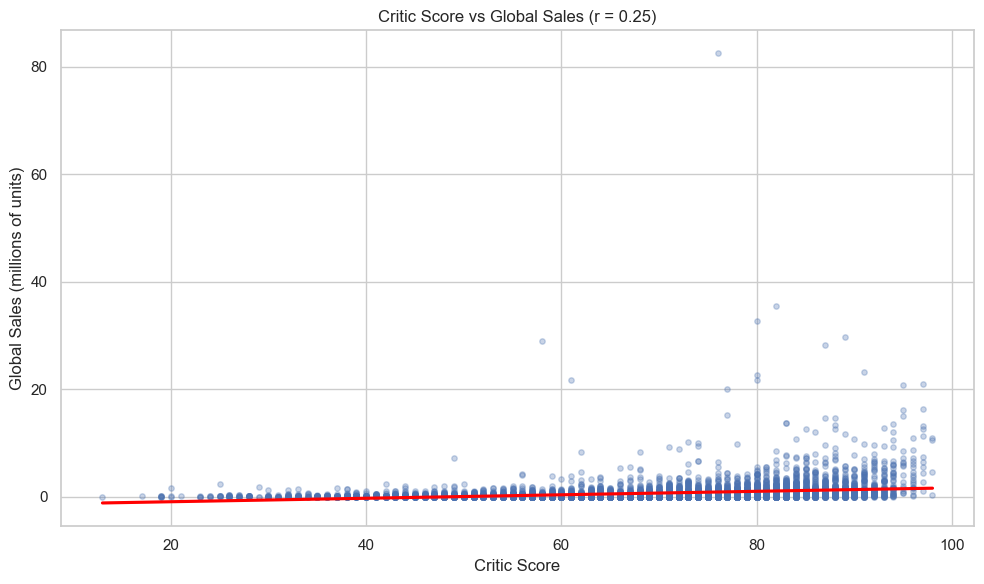

In [23]:
if has_scores:
    plt.figure(figsize=(10, 6))
    sns.regplot(
        data=score_df, x=col["critic"], y=col["global"],
        scatter_kws={"alpha": 0.3, "s": 15}, line_kws={"color": "red"}
    )
    plt.title(f"Critic Score vs Global Sales (r = {corr:.2f})")
    plt.xlabel("Critic Score")
    plt.ylabel("Global Sales (millions of units)")
    plt.tight_layout()
    plt.show()

In [24]:
hit_threshold = df_clean[col["global"]].quantile(0.75)
df_clean["Is_Hit"] = df_clean[col["global"]] >= hit_threshold

MIN_RELEASES = 10

publisher_stats = (
    df_clean.groupby(col["publisher"])
    .agg(Total_Releases=(col["name"], "count"), Hits=("Is_Hit", "sum"))
)
publisher_stats["Hit_Rate"] = publisher_stats["Hits"] / publisher_stats["Total_Releases"]
publisher_stats = publisher_stats[publisher_stats["Total_Releases"] >= MIN_RELEASES]
publisher_stats = publisher_stats.sort_values("Hit_Rate", ascending=False)

print(f"Hit threshold (Global_Sales): {hit_threshold:.2f}M units")
publisher_stats.head(15)

Hit threshold (Global_Sales): 0.47M units


,Total_Releases,Hits,Hit_Rate
Publisher,,,
Sony Computer Entertainment Europe,15,10,0.666667
SquareSoft,52,34,0.653846
Nintendo,700,457,0.652857
989 Studios,14,8,0.571429
Enix Corporation,30,17,0.566667
Universal Interactive,22,12,0.545455
LucasArts,89,47,0.528090
Bethesda Softworks,74,38,0.513514
Electronic Arts,1343,679,0.505585


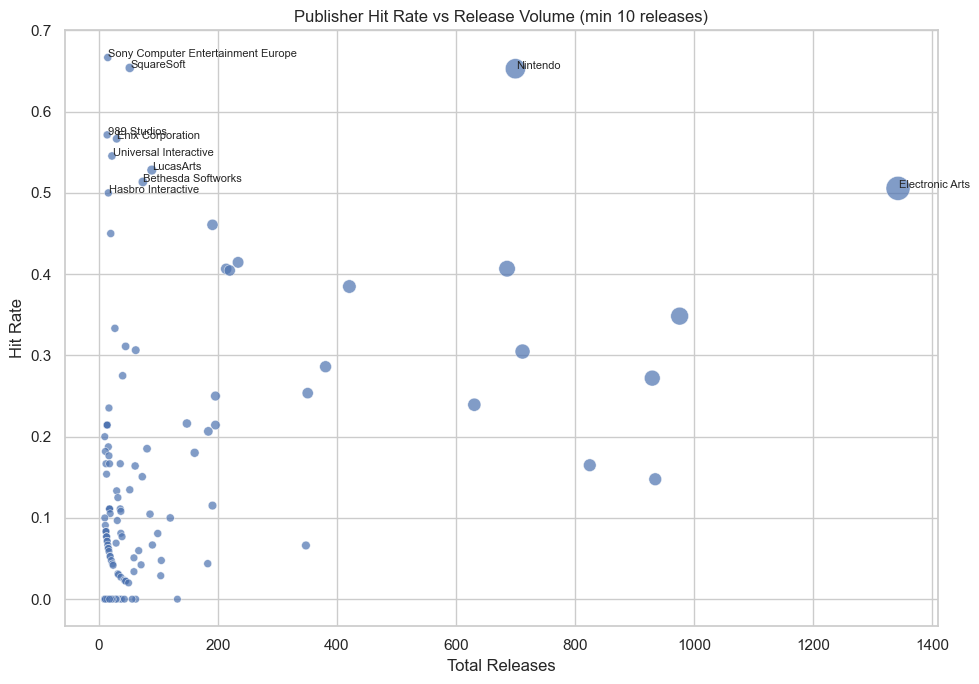

In [25]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=publisher_stats, x="Total_Releases", y="Hit_Rate",
    size="Hits", sizes=(30, 300), legend=False, alpha=0.7
)

top10 = publisher_stats.head(10)
for name, row in top10.iterrows():
    plt.text(row["Total_Releases"] + 1, row["Hit_Rate"], name, fontsize=8)

plt.title(f"Publisher Hit Rate vs Release Volume (min {MIN_RELEASES} releases)")
plt.xlabel("Total Releases")
plt.ylabel("Hit Rate")
plt.tight_layout()
plt.show()